In [11]:
import pandas as pd
import pandas

In [ ]:
df2 = pandas.read_csv(f'../experiment/logs/main.csv')
df1 = pandas.read_csv(f'../experiment/logs/partition.csv')

In [86]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

system2durations = {
          
    }
model = "gat"
for system in ["dgl", "p3", "quiver","edge"]:
    for graph_name in ['orkut']:
    # for graph_name in ['orkut', 'friendster', 'papers100M']:
        if system != "edge":
            row = df2[(df2['graph_name'] == graph_name)\
                        & (df2['model'] == model)\
                            & (df2['system']==system)]
        else: 
            row = df1[(df1['graph_name'] == graph_name) & (df1['model'] == model)\
                        & (df1['batch_size'] == 1024) & \
                            (df1['system'].str.contains('split') &\
                             (df1['partition_type'] == 'ndegree_euniform_bal')\
                                & (df1['sample_mode'] == 'gpu')) ]
        assert(len(row)==1)
        graph_data = {}
        graph_data['Sample'] =  float(row['sampling (s)'])
        graph_data['Load'] = float(row['feature (s)'])
        graph_data['Train'] =  round(float(row['forward (s)']) + float(row['backward (s)']), 1)
        system2durations[system] = graph_data   

/tmp/ipykernel_488680/4229416864.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  graph_data['Sample'] =  float(row['sampling (s)'])
/tmp/ipykernel_488680/4229416864.py:27: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  graph_data['Load'] = float(row['feature (s)'])
/tmp/ipykernel_488680/4229416864.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  graph_data['Train'] =  round(float(row['forward (s)']) + float(row['backward (s)']), 1)


arxiv_logs/orkut_gat_epoch_breakdown_arxiv.pdf


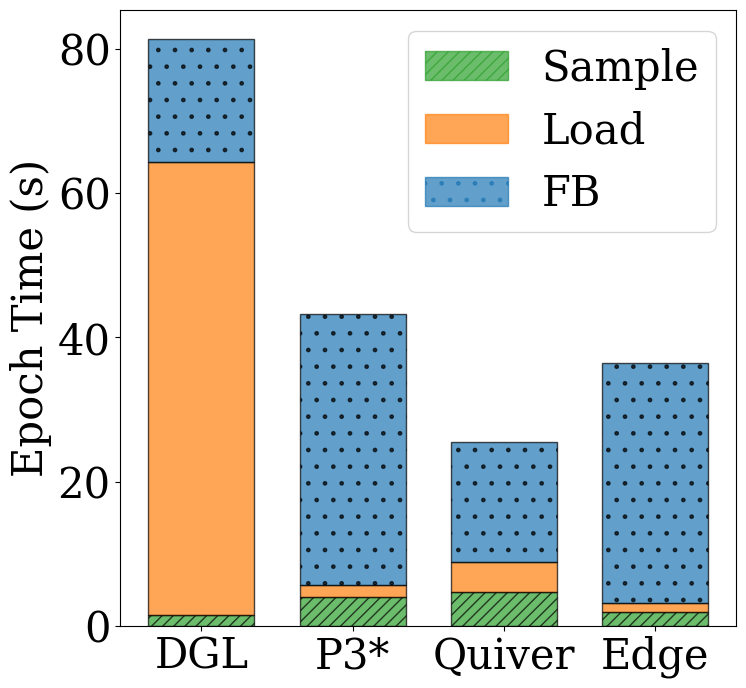

In [88]:

# model = "sage"


systems_label = {
    "dgl":"DGL",
    "p3":"P3*",
    "quiver":"Quiver",
    "edge":"Edge"
}
  
item2color = {"Sample": "tab:green",
             "Train": "tab:blue",
             "Load": "tab:orange"}

font = {'size' : 30, "family": "serif"} 

plt.rc('font', **font)
nsys=3
width = 0.7
fig, ax = plt.subplots(figsize=(8,8))

patterns = [ "///" , "" , "."]
for idx, system in enumerate(["dgl", "p3", "quiver","edge"]):
    # for item, d in durations."items():
    time = system2durations[system]
    bottom = 0
    for i, metric in enumerate(["Sample", "Load", "Train"]):
        p = ax.bar(systems_label[system], time[metric], width, bottom=bottom, hatch = patterns[i], \
                   edgecolor = "black", color=item2color[metric], alpha=0.7)
            
        bottom = bottom + time[metric]

# ax.set_xticklabels(["dgl", "p3","quiver","edge"])
    
# ax.set_title(f"{graph.title()}")
asp = np.diff(ax.get_xlim())[0] / np.diff(ax.get_ylim())[0]
ax.set_aspect(asp)    
ax.set_ylabel("Epoch Time (s)")

# assert(False)
patches = []
patches.append(mpatches.Patch(color=item2color["Sample"], hatch = "///", label='Sample', alpha=0.7))
patches.append(mpatches.Patch(color=item2color["Load"], label='Load', alpha=0.7))
patches.append(mpatches.Patch(color=item2color["Train"], hatch = ".", label='FB', alpha=0.7))
plt.legend(handles=patches, loc = "upper right", ncols = 1)

os.makedirs("plots", exist_ok=True)
# plt.tight_layout()
print(f"arxiv_logs/orkut_{model}_epoch_breakdown_arxiv.pdf")
plt.savefig(f"arxiv_logs/orkut_{model}_epoch_breakdown_arxiv.pdf", dpi=300,bbox_inches="tight" )
plt.show()